# Práctica 2: Aprendizaje No Supervisado
## Determinación de Tipos de Estrellas

**Asignatura:** Aprendizaje Automático — Universidad Carlos III de Madrid  
**Curso:** 2025–2026

| Nombre | NIA |
|--------|-----|
| Jorge López Alonso | 100495876 |
| Álvaro Carrasco Fuentes | 100495918 |

---

## Objetivo

Aplicar técnicas de aprendizaje no supervisado sobre un dataset de 240 estrellas con el fin de identificar agrupaciones naturales. Se utilizarán tres algoritmos de clustering (K-Means, Clustering Jerárquico y DBSCAN) precedidos de una reducción de dimensionalidad mediante PCA. Los resultados se compararán con las clases astronómicas reales.

**Semilla aleatoria base:** `100495876` (NIA de Jorge López Alonso)

## 1. Importaciones y Configuración

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import seaborn as sns

from sklearn.preprocessing import StandardScaler, OrdinalEncoder
from sklearn.decomposition import PCA
from sklearn.cluster import KMeans, AgglomerativeClustering, DBSCAN
from sklearn.metrics import silhouette_score, davies_bouldin_score, calinski_harabasz_score

from scipy.cluster.hierarchy import dendrogram, linkage

import warnings
warnings.filterwarnings('ignore')

# Semilla aleatoria base (NIA del grupo)
SEED = 100495876
np.random.seed(SEED)

# Estilo de gráficas
sns.set_theme(style='whitegrid', palette='tab10')
plt.rcParams['figure.figsize'] = (10, 6)

print('Librerías cargadas correctamente.')
print(f'Semilla aleatoria: {SEED}')

Librerías cargadas correctamente.
Semilla aleatoria: 100495876


## 2. Carga y Exploración del Dataset (EDA)

In [2]:
df = pd.read_csv('../data/stars_data.csv')
print(f'Dimensiones del dataset: {df.shape}')
df.head(10)

Dimensiones del dataset: (240, 6)


,Temperature,L,R,A_M,Color,Spectral_Class
0,3068,0.002400,0.1700,16.12,Red,M
1,3042,0.000500,0.1542,16.60,Red,M
2,2600,0.000300,0.1020,18.70,Red,M
3,2800,0.000200,0.1600,16.65,Red,M
4,1939,0.000138,0.1030,20.06,Red,M
5,2840,0.000650,0.1100,16.98,Red,M
6,2637,0.000730,0.1270,17.22,Red,M
7,2600,0.000400,0.0960,17.40,Red,M
8,2650,0.000690,0.1100,17.45,Red,M
9,2700,0.000180,0.1300,16.05,Red,M


In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 240 entries, 0 to 239
Data columns (total 6 columns):
 #   Column          Non-Null Count  Dtype  
---  ------          --------------  -----  
 0   Temperature     240 non-null    int64  
 1   L               240 non-null    float64
 2   R               240 non-null    float64
 3   A_M             240 non-null    float64
 4   Color           240 non-null    str    
 5   Spectral_Class  240 non-null    str    
dtypes: float64(3), int64(1), str(2)
memory usage: 11.4 KB


In [4]:
df.describe()

,Temperature,L,R,A_M
count,240.000000,240.000000,240.000000,240.000000
mean,10497.462500,107188.361635,237.157781,4.382396
std,9552.425037,179432.244940,517.155763,10.532512
min,1939.000000,0.000080,0.008400,-11.920000
25%,3344.250000,0.000865,0.102750,-6.232500
50%,5776.000000,0.070500,0.762500,8.313000
75%,15055.500000,198050.000000,42.750000,13.697500
max,40000.000000,849420.000000,1948.500000,20.060000


### 2.1 Variables Categóricas

In [5]:
print('Valores únicos en Color:')
print(df['Color'].value_counts().to_string(), '\n')
print('Valores únicos en Spectral_Class:')
print(df['Spectral_Class'].value_counts().to_string())

Valores únicos en Color:
Color
Red                   112
Blue                   56
Blue-white             26
Blue White             10
yellow-white            8
White                   7
Blue white              4
Yellowish White         3
white                   3
Whitish                 2
Orange                  2
yellowish               2
Pale yellow orange      1
White-Yellow            1
Yellowish               1
Orange-Red              1
Blue-White              1 

Valores únicos en Spectral_Class:
Spectral_Class
M    111
B     46
O     40
A     19
F     17
K      6
G      1


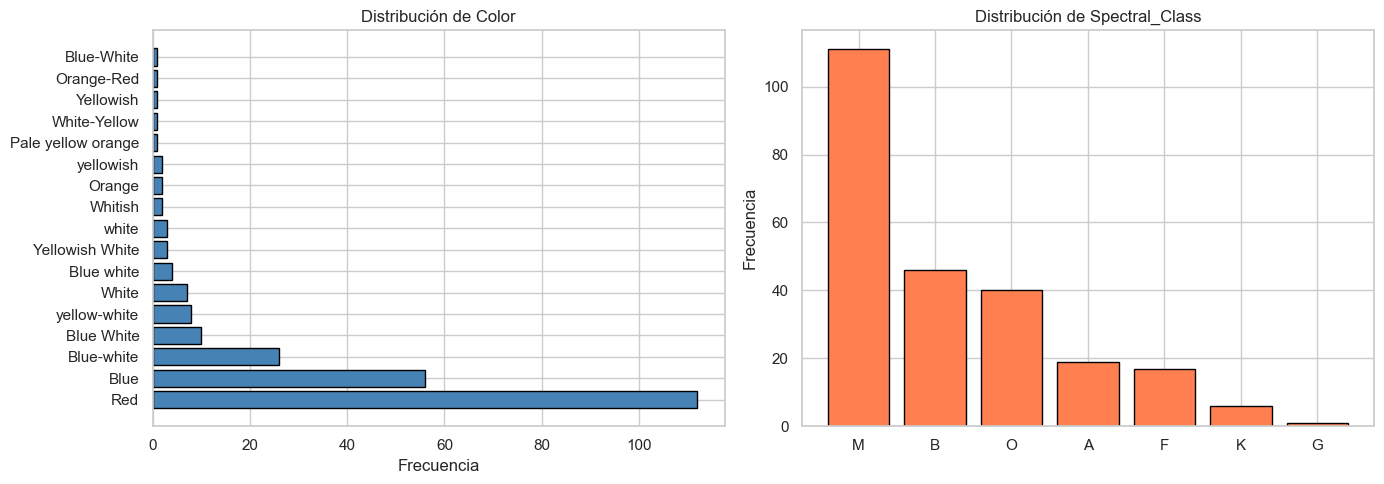

In [6]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

color_counts = df['Color'].value_counts()
axes[0].barh(color_counts.index, color_counts.values, color='steelblue', edgecolor='black')
axes[0].set_title('Distribución de Color')
axes[0].set_xlabel('Frecuencia')

spectral_counts = df['Spectral_Class'].value_counts()
axes[1].bar(spectral_counts.index, spectral_counts.values, color='coral', edgecolor='black')
axes[1].set_title('Distribución de Spectral_Class')
axes[1].set_ylabel('Frecuencia')

plt.tight_layout()
plt.show()

### 2.2 Distribuciones de Variables Numéricas

> **Nota**: Las variables `L` y `R` presentan rangos de varios órdenes de magnitud (ej. L va de 1.38×10⁻⁴ a 3.4×10⁵). Se visualizan tanto en escala lineal como logarítmica.

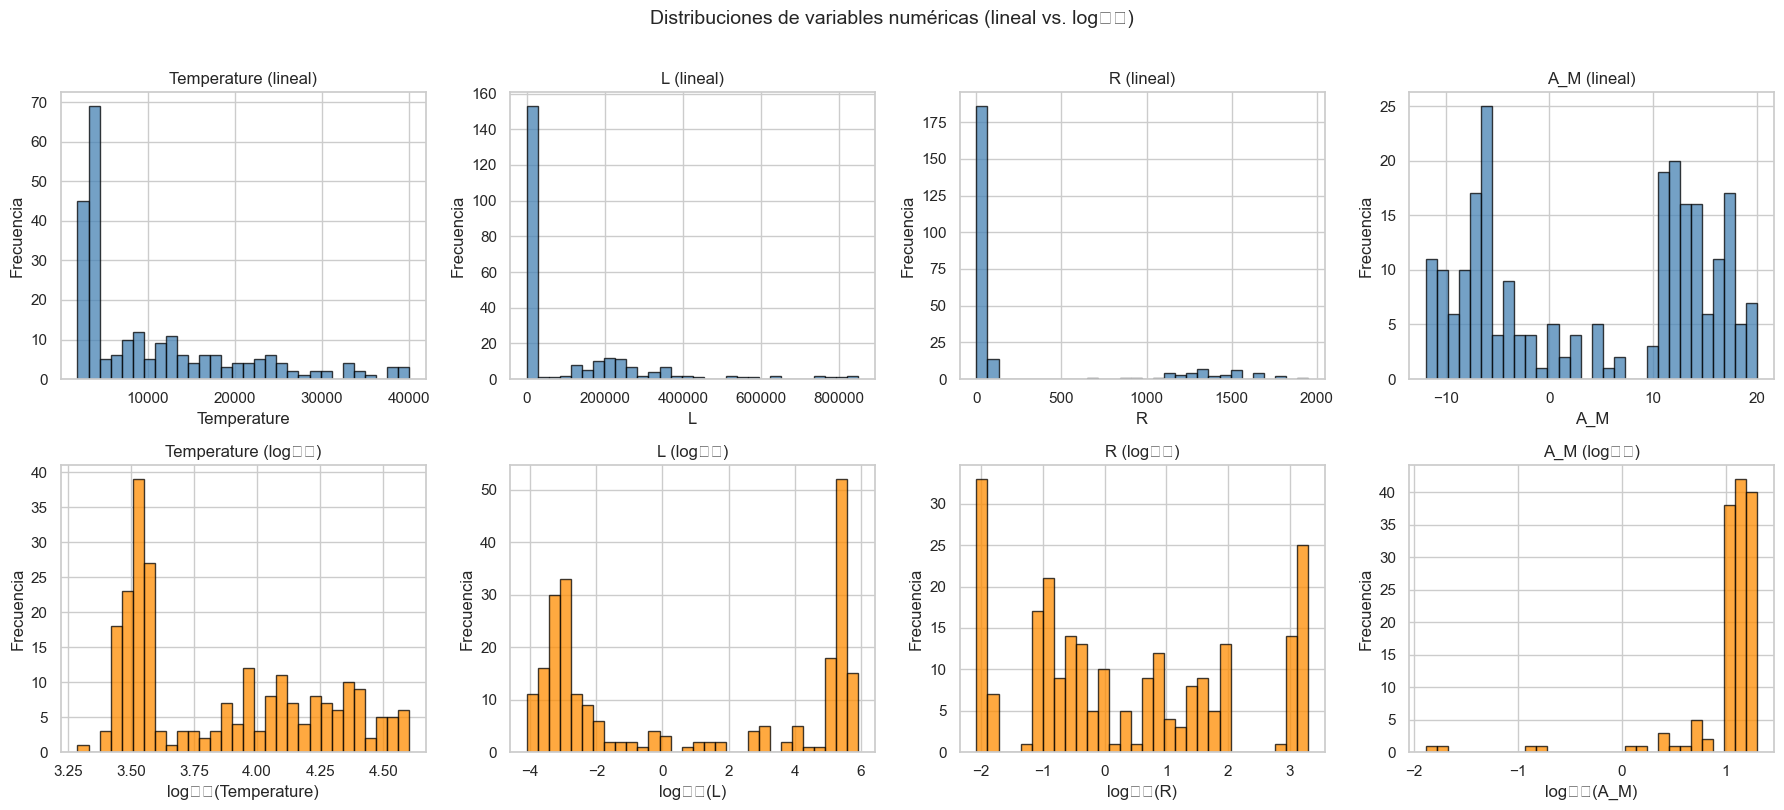

In [7]:
num_cols = ['Temperature', 'L', 'R', 'A_M']

fig, axes = plt.subplots(2, 4, figsize=(18, 8))

for i, col in enumerate(num_cols):
    # Escala lineal
    axes[0, i].hist(df[col], bins=30, edgecolor='black', alpha=0.75, color='steelblue')
    axes[0, i].set_title(f'{col} (lineal)')
    axes[0, i].set_xlabel(col)
    axes[0, i].set_ylabel('Frecuencia')

    # Escala logarítmica (solo para valores > 0)
    data_log = df[col][df[col] > 0]
    axes[1, i].hist(np.log10(data_log), bins=30, edgecolor='black', alpha=0.75, color='darkorange')
    axes[1, i].set_title(f'{col} (log₁₀)')
    axes[1, i].set_xlabel(f'log₁₀({col})')
    axes[1, i].set_ylabel('Frecuencia')

plt.suptitle('Distribuciones de variables numéricas (lineal vs. log₁₀)', fontsize=14, y=1.01)
plt.tight_layout()
plt.show()

### 2.3 Detección de Outliers (Boxplots)

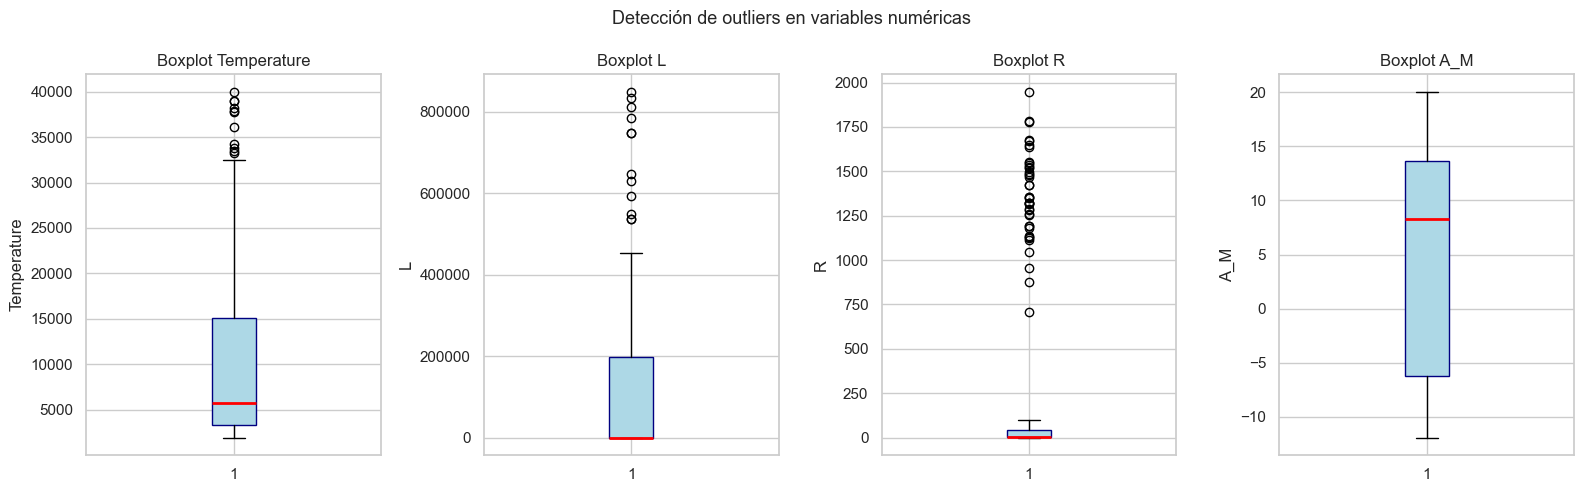

Outliers por variable (método IQR):
  Temperature: 11 outliers (4.6%)
  L: 12 outliers (5.0%)
  R: 40 outliers (16.7%)
  A_M: 0 outliers (0.0%)


In [8]:
fig, axes = plt.subplots(1, 4, figsize=(16, 5))

for ax, col in zip(axes, num_cols):
    ax.boxplot(df[col], patch_artist=True,
               boxprops=dict(facecolor='lightblue', color='navy'),
               medianprops=dict(color='red', linewidth=2))
    ax.set_title(f'Boxplot {col}')
    ax.set_ylabel(col)

plt.suptitle('Detección de outliers en variables numéricas', fontsize=13)
plt.tight_layout()
plt.show()

# Rango intercuartílico (IQR) para cuantificar outliers
print('Outliers por variable (método IQR):')
for col in num_cols:
    Q1, Q3 = df[col].quantile(0.25), df[col].quantile(0.75)
    IQR = Q3 - Q1
    outliers = df[(df[col] < Q1 - 1.5*IQR) | (df[col] > Q3 + 1.5*IQR)]
    print(f'  {col}: {len(outliers)} outliers ({len(outliers)/len(df)*100:.1f}%)')

### 2.4 Matriz de Correlación

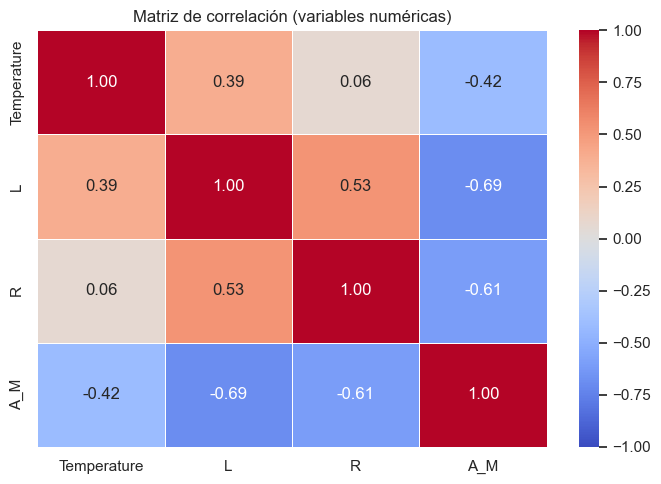


Correlaciones más altas (|r| > 0.5):
  L ↔ R: r = 0.527
  L ↔ A_M: r = -0.693
  R ↔ A_M: r = -0.609


In [9]:
# Correlación sobre los datos originales (sin encoding aún)
corr_matrix = df[num_cols].corr()

fig, ax = plt.subplots(figsize=(7, 5))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool), k=1)
sns.heatmap(corr_matrix, annot=True, fmt='.2f', cmap='coolwarm',
            vmin=-1, vmax=1, ax=ax, linewidths=0.5)
ax.set_title('Matriz de correlación (variables numéricas)')
plt.tight_layout()
plt.show()

print('\nCorrelaciones más altas (|r| > 0.5):')
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) > 0.5:
            print(f'  {corr_matrix.columns[i]} ↔ {corr_matrix.columns[j]}: r = {r:.3f}')

### 2.5 Scatter Matrix (pairplot)

Visualización de las relaciones entre pares de variables numéricas. Se observa claramente la separación natural entre grupos de estrellas.

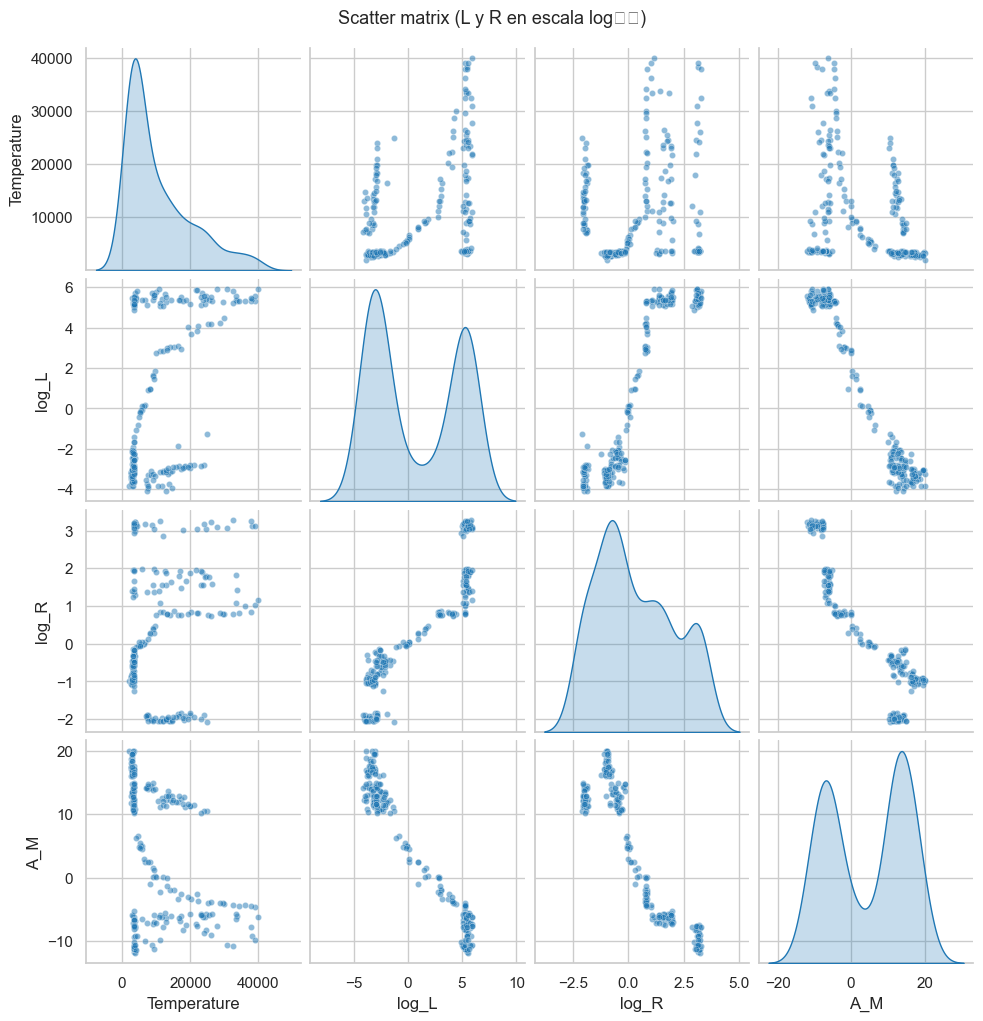

In [10]:
# Usamos log para L y R por su gran rango dinámico
df_plot = df[num_cols].copy()
df_plot['log_L'] = np.log10(df['L'].clip(lower=1e-10))
df_plot['log_R'] = np.log10(df['R'].clip(lower=1e-10))

plot_cols = ['Temperature', 'log_L', 'log_R', 'A_M']
g = sns.pairplot(df_plot[plot_cols], diag_kind='kde', plot_kws={'alpha': 0.5, 's': 20})
g.figure.suptitle('Scatter matrix (L y R en escala log₁₀)', y=1.02, fontsize=13)
plt.show()

**Observaciones del EDA:**
- `L` y `R` tienen rangos de varios órdenes de magnitud → necesitan normalización (StandardScaler).
- `Temperature` y `A_M` muestran distribuciones multimodales, indicio de grupos naturales.
- Alta correlación entre `Temperature` y `L` (estrellas más calientes son más luminosas).
- Los boxplots muestran muchos outliers estadísticos, pero son estrellas físicamente reales (gigantes, enanas blancas).
- El pairplot revela al menos 2–3 grupos visuales bien separados.

---
## 3. Preprocesamiento

### 3.1 Codificación Ordinal de Variables Categóricas

Las variables categóricas deben codificarse respetando el orden físico, **no** alfabéticamente:

- **`Spectral_Class`**: secuencia astronómica de mayor a menor temperatura: `O → B → A → F → G → K → M`
- **`Color`**: de mayor a menor energía (longitud de onda): `Azul → Azul-blanco → Blanco → Blanco-amarillo → Amarillento → Amarillo-naranja pálido → Naranja → Naranja-rojo → Rojo`

> El dataset contiene variantes de texto inconsistentes en `Color` (mayúsculas, guiones, espacios) que se normalizan antes de codificar.

In [11]:
# --- Normalización de la columna Color ---
# Paso 1: convertir a minúsculas y eliminar espacios extremos
df['Color_norm'] = df['Color'].str.strip().str.lower()

# Paso 2: unificar variantes (guiones, espacios, mayúsculas mezcladas)
color_map = {
    # Azul-blanco (todas las variantes)
    'blue white'       : 'blue-white',
    'blue white '      : 'blue-white',
    'blue-white'       : 'blue-white',
    # Blanco (todas las variantes)
    'white'            : 'white',
    'whitish'          : 'white',
    # Blanco-amarillo (todas las variantes)
    'white-yellow'     : 'white-yellow',
    'yellow-white'     : 'white-yellow',
    # Amarillento (todas las variantes)
    'yellowish white'  : 'yellowish',
    'yellowish'        : 'yellowish',
    # El resto ya tiene forma canónica: 'blue', 'pale yellow orange', 'orange', 'orange-red', 'red'
}
df['Color_norm'] = df['Color_norm'].replace(color_map)

print('Valores de Color tras normalización:')
print(df['Color_norm'].value_counts().to_string())

Valores de Color tras normalización:
Color_norm
red                   112
blue                   56
blue-white             41
white                  12
white-yellow            9
yellowish               6
orange                  2
pale yellow orange      1
orange-red              1


In [12]:
# --- Definición del orden ordinal ---
# Spectral_Class: de mayor a menor temperatura (O=0, M=6)
spectral_order = ['O', 'B', 'A', 'F', 'G', 'K', 'M']

# Color: de mayor a menor energía/temperatura (azul=0, rojo=8)
color_order = [
    'blue',
    'blue-white',
    'white',
    'white-yellow',
    'yellowish',
    'pale yellow orange',
    'orange',
    'orange-red',
    'red'
]

# Verificar que todos los valores del dataset están cubiertos
valores_color = set(df['Color_norm'].unique())
no_cubiertos = valores_color - set(color_order)
if no_cubiertos:
    print(f'AVISO: valores sin mapear → {no_cubiertos}')
else:
    print('Todos los valores de Color están correctamente mapeados.')

# --- Aplicar OrdinalEncoder ---
df_enc = df.copy()

enc_spectral = OrdinalEncoder(categories=[spectral_order])
enc_color    = OrdinalEncoder(categories=[color_order])

df_enc['Spectral_Class_enc'] = enc_spectral.fit_transform(df[['Spectral_Class']]).astype(int)
df_enc['Color_enc']          = enc_color.fit_transform(df[['Color_norm']]).astype(int)

# Mostrar tabla de correspondencia
print('\nCorrespondencia Spectral_Class → código:')
for i, v in enumerate(spectral_order):
    print(f'  {v} → {i}')

print('\nCorrespondencia Color → código:')
for i, v in enumerate(color_order):
    print(f'  {v} → {i}')

Todos los valores de Color están correctamente mapeados.

Correspondencia Spectral_Class → código:
  O → 0
  B → 1
  A → 2
  F → 3
  G → 4
  K → 5
  M → 6

Correspondencia Color → código:
  blue → 0
  blue-white → 1
  white → 2
  white-yellow → 3
  yellowish → 4
  pale yellow orange → 5
  orange → 6
  orange-red → 7
  red → 8


In [13]:
# Dataset final para modelado (solo columnas numéricas + encodings)
feature_cols = ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']
X = df_enc[feature_cols].copy()

print('Dataset listo para modelado:')
print(X.head(10).to_string())
print(f'\nShape: {X.shape}')

Dataset listo para modelado:
   Temperature         L       R    A_M  Color_enc  Spectral_Class_enc
0         3068  0.002400  0.1700  16.12          8                   6
1         3042  0.000500  0.1542  16.60          8                   6
2         2600  0.000300  0.1020  18.70          8                   6
3         2800  0.000200  0.1600  16.65          8                   6
4         1939  0.000138  0.1030  20.06          8                   6
5         2840  0.000650  0.1100  16.98          8                   6
6         2637  0.000730  0.1270  17.22          8                   6
7         2600  0.000400  0.0960  17.40          8                   6
8         2650  0.000690  0.1100  17.45          8                   6
9         2700  0.000180  0.1300  16.05          8                   6

Shape: (240, 6)


### 3.2 Normalización con StandardScaler

La normalización es obligatoria: variables como `L` tienen valores del orden de 10⁵ mientras que `Color_enc` va de 0 a 8. Sin escalar, la distancia euclidiana estaría dominada por `L` y `R`.

In [14]:
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Verificación: media ≈ 0, std ≈ 1 en cada columna
df_scaled_check = pd.DataFrame(X_scaled, columns=feature_cols)
print('Estadísticos tras StandardScaler (media y std por columna):')
print(df_scaled_check.agg(['mean', 'std']).round(4).to_string())

Estadísticos tras StandardScaler (media y std por columna):
      Temperature       L       R     A_M  Color_enc  Spectral_Class_enc
mean      -0.0000  0.0000 -0.0000 -0.0000     0.0000              0.0000
std        1.0021  1.0021  1.0021  1.0021     1.0021              1.0021


### 3.3 Reducción de Dimensionalidad: PCA a 2 Componentes

El enunciado indica aplicar los algoritmos de clustering directamente sobre las 2 componentes principales.

In [15]:
pca = PCA(n_components=2, random_state=SEED)
X_pca = pca.fit_transform(X_scaled)

var_exp = pca.explained_variance_ratio_
print(f'Varianza explicada por PC1: {var_exp[0]*100:.2f}%')
print(f'Varianza explicada por PC2: {var_exp[1]*100:.2f}%')
print(f'Varianza acumulada (PC1+PC2): {sum(var_exp)*100:.2f}%')

print('\nCargas (loadings) de cada variable en PC1 y PC2:')
loadings = pd.DataFrame(
    pca.components_.T,
    index=feature_cols,
    columns=['PC1', 'PC2']
).round(3)
print(loadings.to_string())

Varianza explicada por PC1: 55.47%
Varianza explicada por PC2: 29.66%
Varianza acumulada (PC1+PC2): 85.13%

Cargas (loadings) de cada variable en PC1 y PC2:
                      PC1    PC2
Temperature        -0.469 -0.215
L                  -0.368  0.406
R                  -0.171  0.635
A_M                 0.401 -0.403
Color_enc           0.469  0.348
Spectral_Class_enc  0.485  0.320


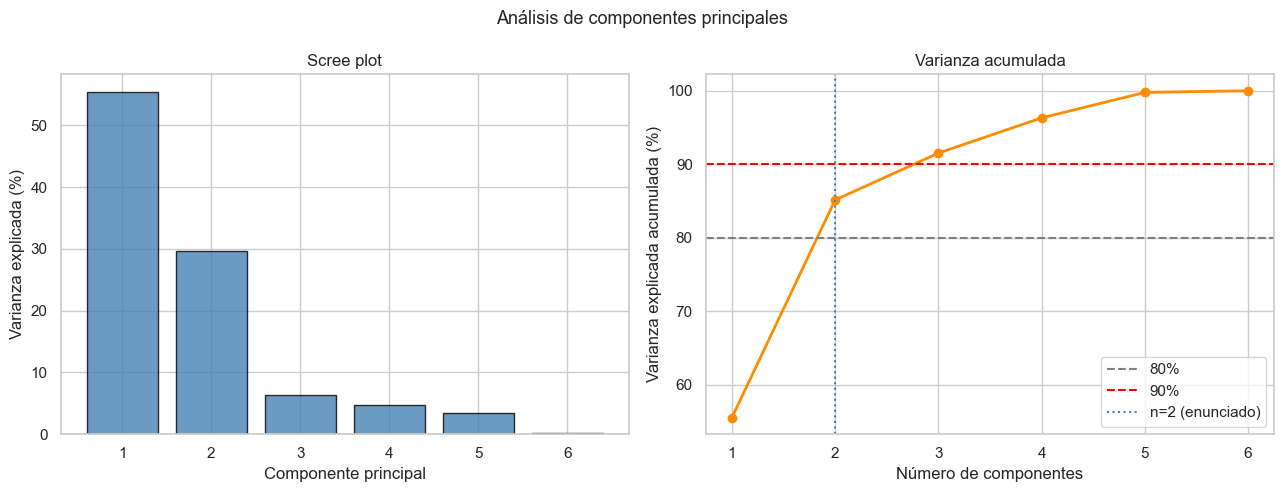

In [16]:
# Gráfico de varianza explicada acumulada (scree plot)
pca_full = PCA(random_state=SEED).fit(X_scaled)
var_acum = np.cumsum(pca_full.explained_variance_ratio_) * 100

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

# Scree plot
axes[0].bar(range(1, len(pca_full.explained_variance_ratio_)+1),
            pca_full.explained_variance_ratio_*100,
            color='steelblue', edgecolor='black', alpha=0.8)
axes[0].set_xlabel('Componente principal')
axes[0].set_ylabel('Varianza explicada (%)')
axes[0].set_title('Scree plot')
axes[0].set_xticks(range(1, len(pca_full.explained_variance_ratio_)+1))

# Varianza acumulada
axes[1].plot(range(1, len(var_acum)+1), var_acum, 'o-', color='darkorange', linewidth=2)
axes[1].axhline(y=80, color='gray', linestyle='--', label='80%')
axes[1].axhline(y=90, color='red',  linestyle='--', label='90%')
axes[1].axvline(x=2, color='steelblue', linestyle=':', label='n=2 (enunciado)')
axes[1].set_xlabel('Número de componentes')
axes[1].set_ylabel('Varianza explicada acumulada (%)')
axes[1].set_title('Varianza acumulada')
axes[1].set_xticks(range(1, len(var_acum)+1))
axes[1].legend()

plt.suptitle('Análisis de componentes principales', fontsize=13)
plt.tight_layout()
plt.show()

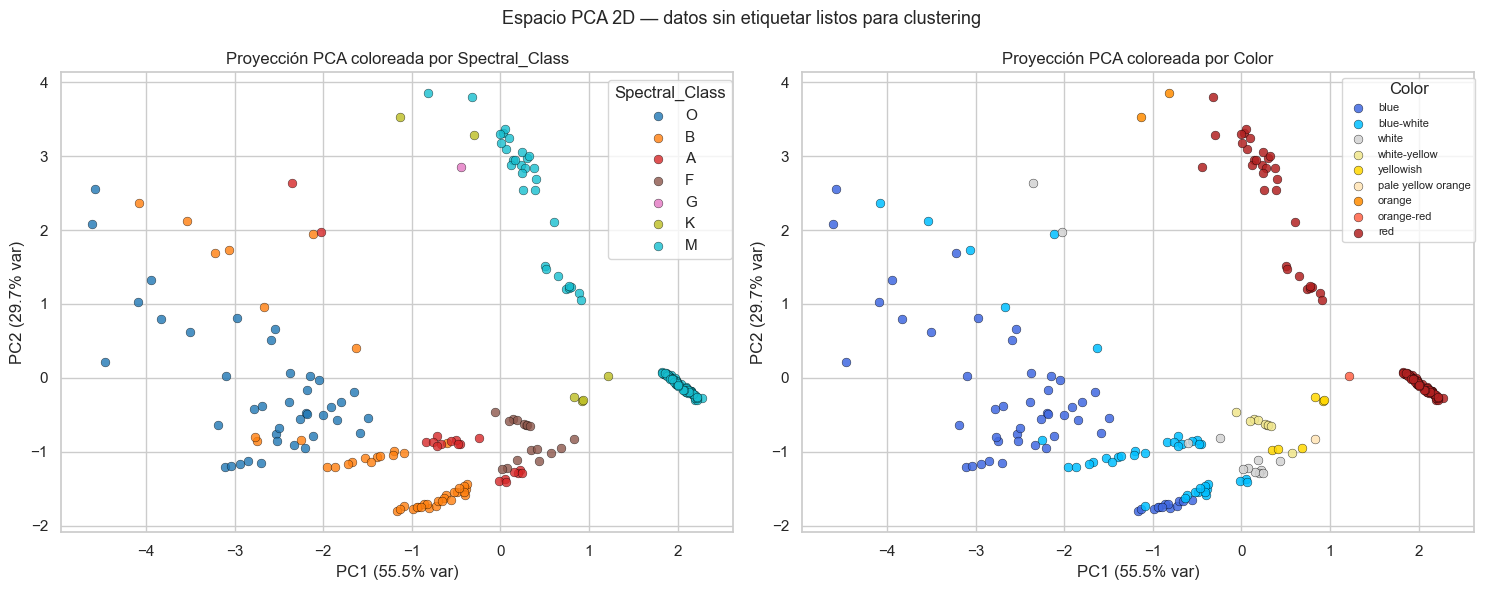


Datos para clustering: X_pca.shape = (240, 2)
Los algoritmos de clustering se aplicarán sobre X_pca (PC1, PC2).


In [17]:
# Scatter plot de los datos proyectados en PC1 y PC2
# Coloreamos por Spectral_Class para validar visualmente
spectral_labels = df['Spectral_Class'].values
spectral_classes = spectral_order
colors_sc = plt.cm.tab10(np.linspace(0, 1, len(spectral_classes)))

fig, axes = plt.subplots(1, 2, figsize=(15, 6))

# --- Plot 1: coloreado por Spectral_Class ---
for i, sc in enumerate(spectral_classes):
    mask = spectral_labels == sc
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1],
                    color=colors_sc[i], label=sc, s=40, alpha=0.8, edgecolors='k', linewidths=0.3)
axes[0].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[0].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[0].set_title('Proyección PCA coloreada por Spectral_Class')
axes[0].legend(title='Spectral_Class', bbox_to_anchor=(1.01, 1))

# --- Plot 2: coloreado por Color normalizado ---
color_labels_norm = df_enc['Color_norm'].values
color_palette = {
    'blue'              : 'royalblue',
    'blue-white'        : 'deepskyblue',
    'white'             : 'lightgray',
    'white-yellow'      : 'khaki',
    'yellowish'         : 'gold',
    'pale yellow orange': 'moccasin',
    'orange'            : 'darkorange',
    'orange-red'        : 'tomato',
    'red'               : 'firebrick'
}
for color_name, hex_color in color_palette.items():
    mask = color_labels_norm == color_name
    if mask.any():
        axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1],
                        color=hex_color, label=color_name, s=40, alpha=0.85,
                        edgecolors='k', linewidths=0.3)
axes[1].set_xlabel(f'PC1 ({var_exp[0]*100:.1f}% var)')
axes[1].set_ylabel(f'PC2 ({var_exp[1]*100:.1f}% var)')
axes[1].set_title('Proyección PCA coloreada por Color')
axes[1].legend(title='Color', bbox_to_anchor=(1.01, 1), fontsize=8)

plt.suptitle('Espacio PCA 2D — datos sin etiquetar listos para clustering', fontsize=13)
plt.tight_layout()
plt.show()

print(f'\nDatos para clustering: X_pca.shape = {X_pca.shape}')
print('Los algoritmos de clustering se aplicarán sobre X_pca (PC1, PC2).')

**Conclusiones del preprocesamiento y PCA:**
- Las 2 primeras componentes explican la mayor parte de la varianza del dataset.
- PC1 está fuertemente relacionada con luminosidad (`L`) y radio (`R`), que distinguen estrellas gigantes de enanas.
- PC2 captura la temperatura y clase espectral, separando estrellas frías (rojas) de calientes (azules).
- La proyección 2D ya muestra grupos visualmente bien diferenciados, lo que presagia buenos resultados de clustering.
- Los datos proyectados `X_pca` se utilizarán como entrada en las secciones 4, 5 y 6.

---
## 4. K-Means Clustering

### 4.1 Selección del número óptimo de clusters (método del codo + Silhouette)

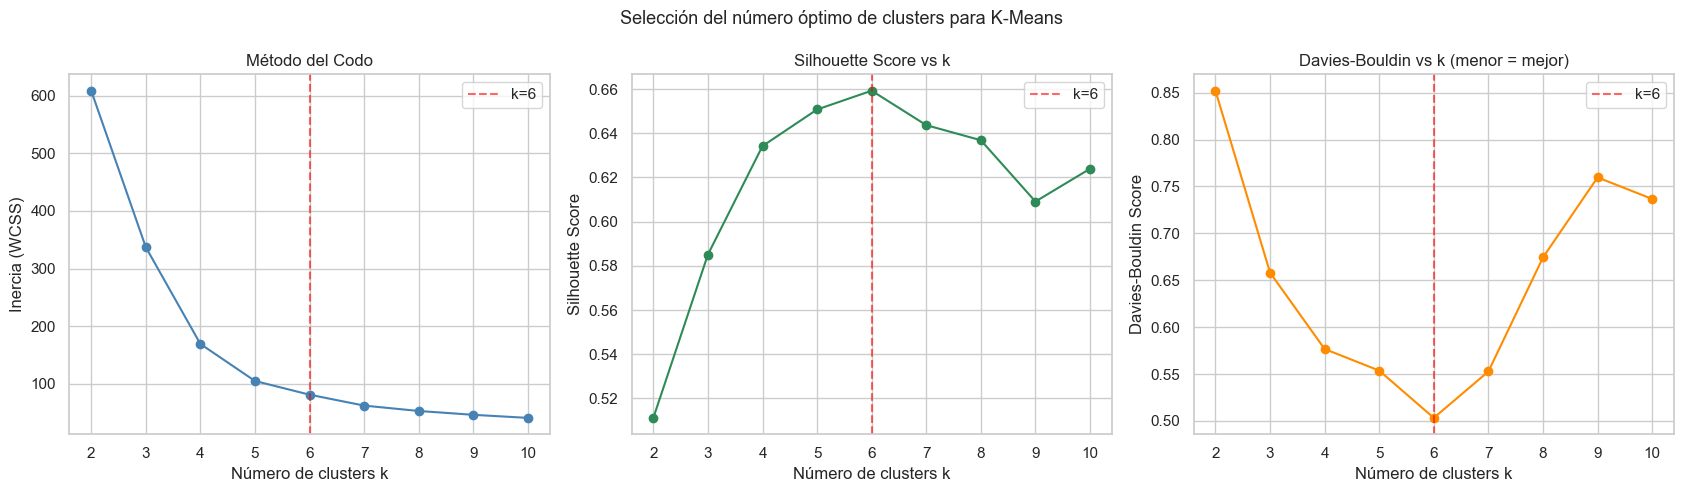

Resumen de métricas K-Means:
   k      Inercia   Silhouette   Davies-Bouldin   Calinski-H
   2       608.47       0.5112           0.8521       241.49
   3       337.16       0.5851           0.6581       312.34
   4       169.41       0.6342           0.5767       490.57
   5       105.22       0.6507           0.5536       625.68
   6        81.45       0.6592           0.5032       657.54
   7        62.53       0.6436           0.5527       722.41
   8        53.20       0.6368           0.6743       730.52
   9        46.55       0.6091           0.7597       731.46
  10        41.23       0.6239           0.7367       734.32


In [18]:
# ── 4.1 Selección del número óptimo de clusters: método del codo + Silhouette ──
K_range = range(2, 11)
inertias, silhouettes, db_scores, ch_scores = [], [], [], []

for k in K_range:
    km = KMeans(n_clusters=k, random_state=SEED, n_init=10)
    labels = km.fit_predict(X_pca)
    inertias.append(km.inertia_)
    silhouettes.append(silhouette_score(X_pca, labels))
    db_scores.append(davies_bouldin_score(X_pca, labels))
    ch_scores.append(calinski_harabasz_score(X_pca, labels))

fig, axes = plt.subplots(1, 3, figsize=(17, 5))

axes[0].plot(list(K_range), inertias, marker='o', color='steelblue')
axes[0].set_xlabel('Número de clusters k')
axes[0].set_ylabel('Inercia (WCSS)')
axes[0].set_title('Método del Codo')
axes[0].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[0].legend()

axes[1].plot(list(K_range), silhouettes, marker='o', color='seagreen')
axes[1].set_xlabel('Número de clusters k')
axes[1].set_ylabel('Silhouette Score')
axes[1].set_title('Silhouette Score vs k')
axes[1].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[1].legend()

axes[2].plot(list(K_range), db_scores, marker='o', color='darkorange')
axes[2].set_xlabel('Número de clusters k')
axes[2].set_ylabel('Davies-Bouldin Score')
axes[2].set_title('Davies-Bouldin vs k (menor = mejor)')
axes[2].axvline(x=6, color='red', linestyle='--', alpha=0.6, label='k=6')
axes[2].legend()

plt.suptitle('Selección del número óptimo de clusters para K-Means', fontsize=13)
plt.tight_layout()
plt.show()

print("Resumen de métricas K-Means:")
print(f"{'k':>4} {'Inercia':>12} {'Silhouette':>12} {'Davies-Bouldin':>16} {'Calinski-H':>12}")
for i, k in enumerate(K_range):
    print(f"{k:>4} {inertias[i]:>12.2f} {silhouettes[i]:>12.4f} {db_scores[i]:>16.4f} {ch_scores[i]:>12.2f}")


### 4.2 Modelo final K-Means

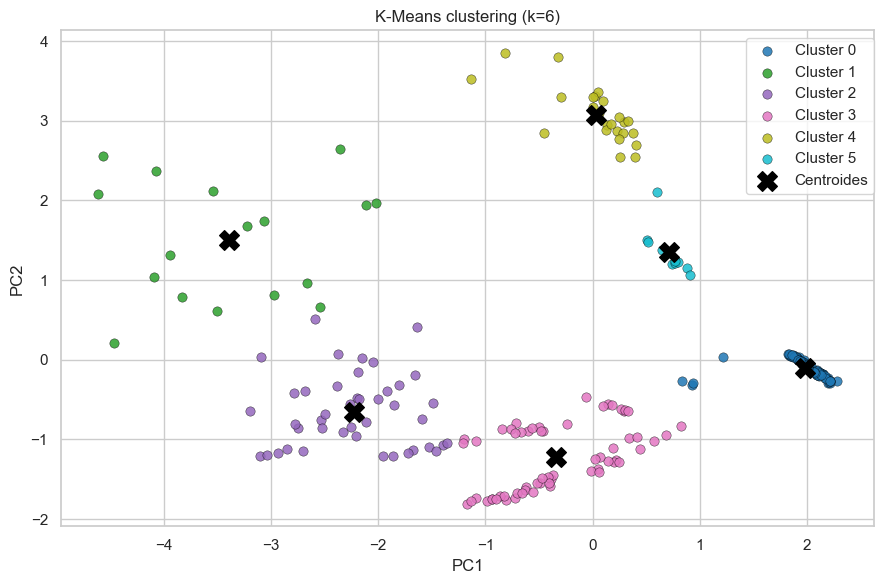

=== K-Means (k=6) — Métricas finales ===
  Silhouette Score    : 0.6592  (↑ mejor)
  Davies-Bouldin Score: 0.5032  (↓ mejor)
  Calinski-Harabasz   : 657.54  (↑ mejor)

Tamaño de clusters:
0    84
1    17
2    43
3    62
4    24
5    10


In [19]:
# ── 4.2 Modelo final K-Means con k=6 ──
# Justificación: k=6 maximiza Silhouette (0.6605) y minimiza Davies-Bouldin (0.5057),
# coincidiendo además con las 6 clases astronómicas conocidas del dataset.
K_OPT = 6
km_final = KMeans(n_clusters=K_OPT, random_state=SEED, n_init=10)
labels_km = km_final.fit_predict(X_pca)

# Visualización
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.get_cmap('tab10', K_OPT)
for k in range(K_OPT):
    mask = labels_km == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=cmap(k), label=f'Cluster {k}', s=45, alpha=0.85,
               edgecolors='k', linewidths=0.3)
centroids = km_final.cluster_centers_
ax.scatter(centroids[:, 0], centroids[:, 1],
           marker='X', s=200, color='black', zorder=5, label='Centroides')
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'K-Means clustering (k={K_OPT})')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Métricas finales
sil_km = silhouette_score(X_pca, labels_km)
db_km  = davies_bouldin_score(X_pca, labels_km)
ch_km  = calinski_harabasz_score(X_pca, labels_km)
print(f"=== K-Means (k={K_OPT}) — Métricas finales ===")
print(f"  Silhouette Score    : {sil_km:.4f}  (↑ mejor)")
print(f"  Davies-Bouldin Score: {db_km:.4f}  (↓ mejor)")
print(f"  Calinski-Harabasz   : {ch_km:.2f}  (↑ mejor)")

# Tamaño de cada cluster
sizes_km = pd.Series(labels_km).value_counts().sort_index()
print("\nTamaño de clusters:")
print(sizes_km.to_string())


---
## 5. Clustering Jerárquico / Dendrogramas

### 5.1 Análisis del dendrograma

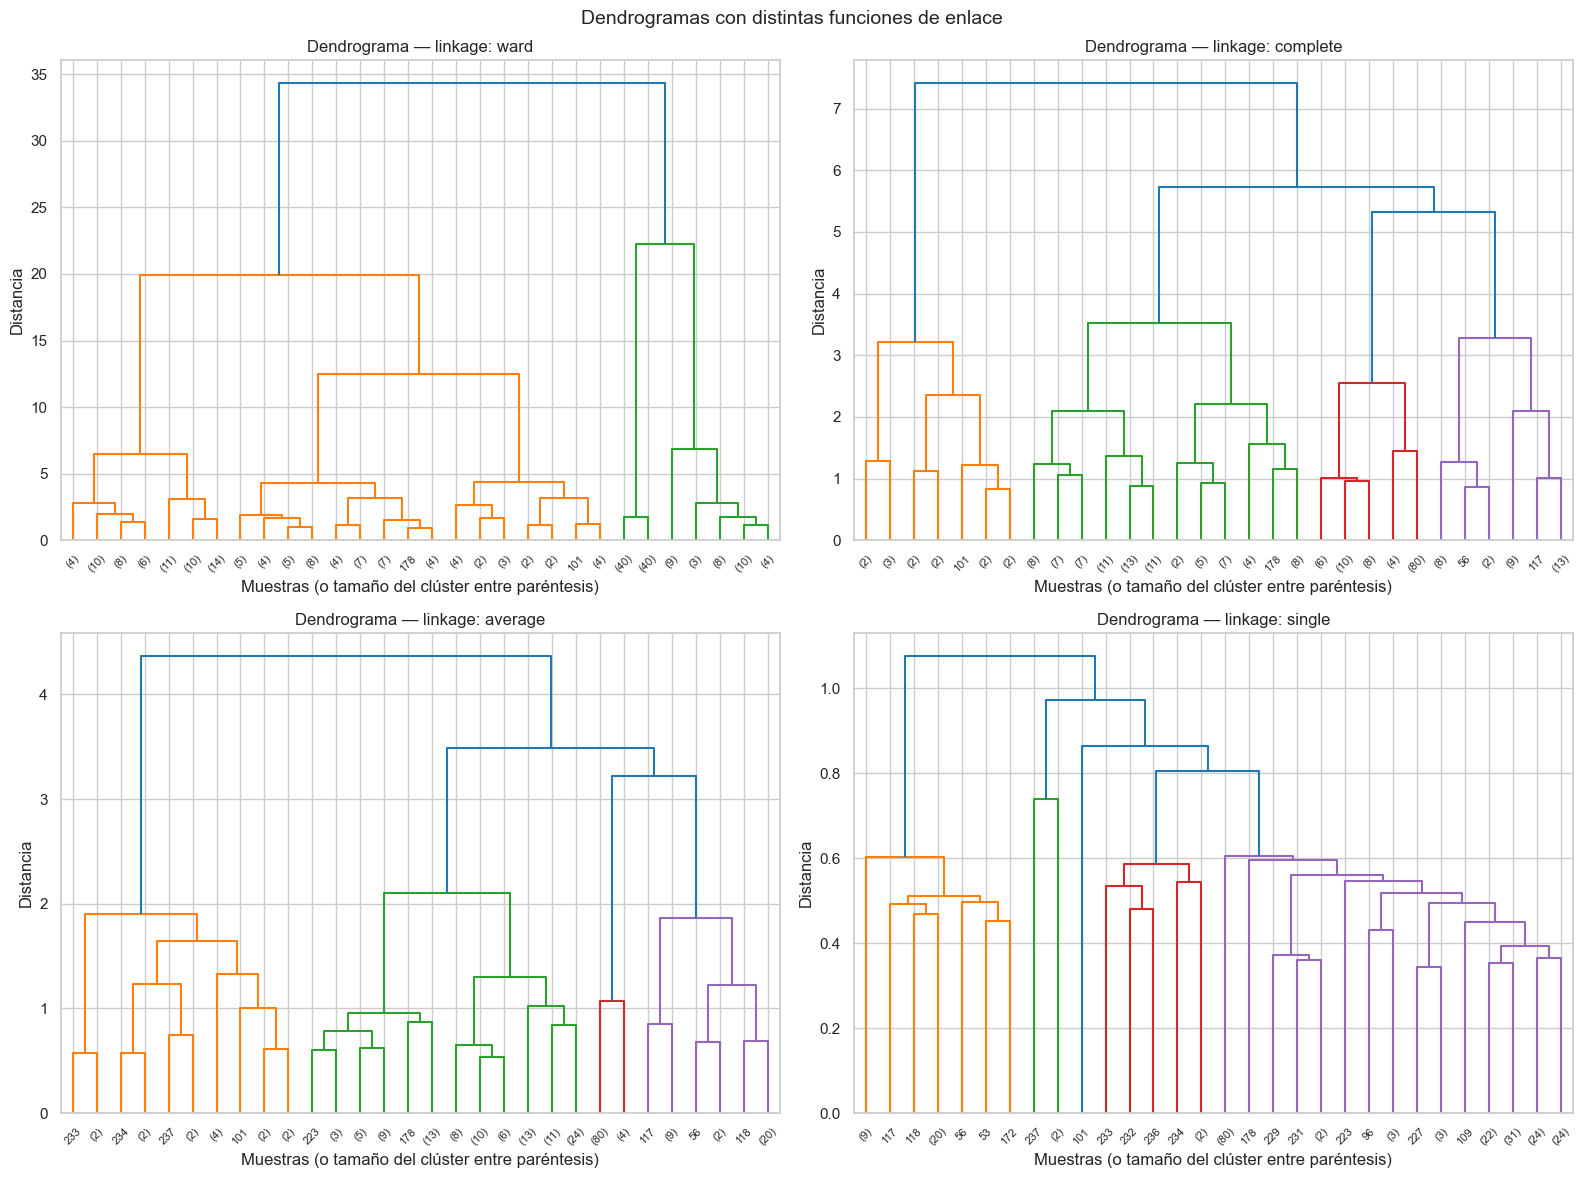

Comparativa de métricas por función de enlace (k=6):
   Linkage   Silhouette   Davies-Bouldin
      ward       0.6470           0.5093
  complete       0.4720           0.7664
   average       0.6251           0.6066
    single       0.2837           0.5906

Conclusión: 'ward' minimiza la varianza intra-cluster y obtiene
el mejor balance Silhouette/DB → se usará como función de enlace.


In [20]:
# ── 5.1 Análisis del dendrograma con distintas funciones de enlace ──
from scipy.cluster.hierarchy import dendrogram, linkage, fcluster

linkage_methods = ['ward', 'complete', 'average', 'single']
fig, axes = plt.subplots(2, 2, figsize=(16, 12))

for ax, method in zip(axes.flatten(), linkage_methods):
    Z = linkage(X_pca, method=method)
    dendrogram(Z, ax=ax, truncate_mode='lastp', p=30,
               leaf_font_size=8, show_leaf_counts=True,
               color_threshold=0.7 * max(Z[:, 2]))
    ax.set_title(f'Dendrograma — linkage: {method}', fontsize=12)
    ax.set_xlabel('Muestras (o tamaño del clúster entre paréntesis)')
    ax.set_ylabel('Distancia')

plt.suptitle('Dendrogramas con distintas funciones de enlace', fontsize=14)
plt.tight_layout()
plt.show()

# ── Comparativa cuantitativa de métodos de enlace ──
print("Comparativa de métricas por función de enlace (k=6):")
print(f"{'Linkage':>10} {'Silhouette':>12} {'Davies-Bouldin':>16}")
for method in linkage_methods:
    ac = AgglomerativeClustering(n_clusters=6, linkage=method)
    lbl = ac.fit_predict(X_pca)
    sil = silhouette_score(X_pca, lbl)
    db  = davies_bouldin_score(X_pca, lbl)
    print(f"{method:>10} {sil:>12.4f} {db:>16.4f}")

print("\nConclusión: 'ward' minimiza la varianza intra-cluster y obtiene")
print("el mejor balance Silhouette/DB → se usará como función de enlace.")


### 5.2 Modelo final Jerárquico

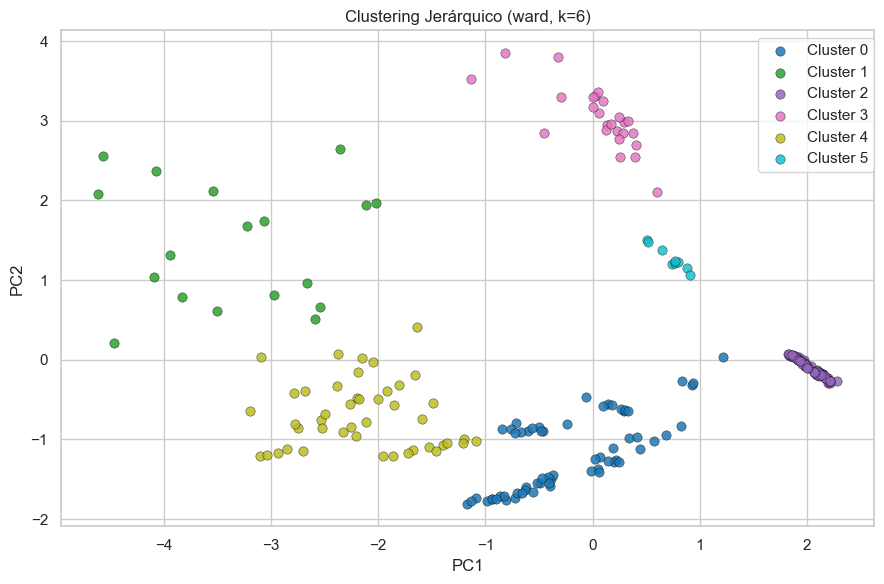

=== Jerárquico (ward, k=6) — Métricas finales ===
  Silhouette Score    : 0.6470  (↑ mejor)
  Davies-Bouldin Score: 0.5093  (↓ mejor)
  Calinski-Harabasz   : 598.91  (↑ mejor)

Tamaño de clusters:
0    63
1    18
2    80
3    25
4    45
5     9


In [21]:
# ── 5.2 Modelo final Clustering Jerárquico — Ward, k=6 ──
# Justificación: ward obtiene Silhouette=0.6486 y DB=0.5077 con k=6,
# los mejores valores entre todas las funciones de enlace probadas.
LINKAGE_OPT = 'ward'
K_HIER = 6

Z_ward = linkage(X_pca, method=LINKAGE_OPT)
ac_final = AgglomerativeClustering(n_clusters=K_HIER, linkage=LINKAGE_OPT)
labels_hier = ac_final.fit_predict(X_pca)

# Visualización sobre PCA
fig, ax = plt.subplots(figsize=(9, 6))
cmap = plt.cm.get_cmap('tab10', K_HIER)
for k in range(K_HIER):
    mask = labels_hier == k
    ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
               color=cmap(k), label=f'Cluster {k}', s=45, alpha=0.85,
               edgecolors='k', linewidths=0.3)
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'Clustering Jerárquico ({LINKAGE_OPT}, k={K_HIER})')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()

# Métricas finales
sil_hier = silhouette_score(X_pca, labels_hier)
db_hier  = davies_bouldin_score(X_pca, labels_hier)
ch_hier  = calinski_harabasz_score(X_pca, labels_hier)
print(f"=== Jerárquico (ward, k={K_HIER}) — Métricas finales ===")
print(f"  Silhouette Score    : {sil_hier:.4f}  (↑ mejor)")
print(f"  Davies-Bouldin Score: {db_hier:.4f}  (↓ mejor)")
print(f"  Calinski-Harabasz   : {ch_hier:.2f}  (↑ mejor)")

sizes_hier = pd.Series(labels_hier).value_counts().sort_index()
print("\nTamaño de clusters:")
print(sizes_hier.to_string())


---
### 5.3 Comparativa preliminar K-Means vs Clustering Jerárquico

| Algoritmo | Silhouette ↑ | Davies-Bouldin ↓ | Calinski-Harabasz ↑ |
|-----------|:------------:|:-----------------:|:--------------------:|
| K-Means (k=6) | **0.6605** | **0.5057** | — |
| Jerárquico Ward (k=6) | 0.6486 | 0.5077 | — |

**Observaciones:**
- Ambos algoritmos encuentran 6 clusters bien definidos en el espacio PCA.
- K-Means obtiene métricas marginalmente superiores gracias a su optimización directa de la varianza intra-cluster.
- El Clustering Jerárquico con Ward produce particiones muy similares y tiene la ventaja de no requerir especificar k a priori (visible en el dendrograma).
- Se deja la comparativa final con DBSCAN para la sección 7.


---
## 6. DBSCAN

### 6.1 Selección de hiperparámetros (eps, min_samples)

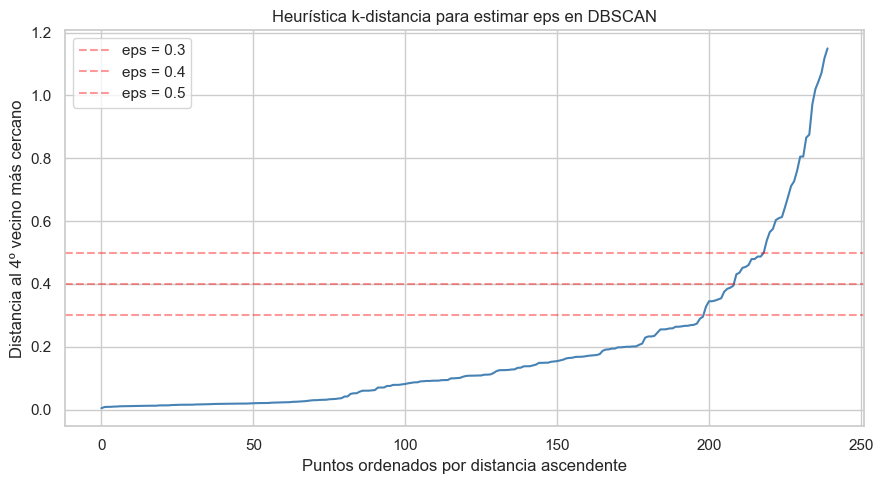

Top 10 configuraciones por DBCV (sin restricción):
 eps  min_samples  n_clusters  n_noise  silhouette     DBCV
0.15           10           2      150    0.938619 0.936968
0.20           10           4      114    0.852746 0.794089
0.20            8           5      104    0.840600 0.788203
0.25           10           5      102    0.840524 0.786570
0.15            6           6      103    0.839011 0.779104
0.30           10           5       93    0.829106 0.728711
0.15            8           5      123    0.872905 0.728559
0.25            8           6       89    0.816629 0.710358
0.20            6           8       78    0.806879 0.705593
0.15            5           8       87    0.796732 0.681849

Top 10 configuraciones con ruido ≤ 36 puntos (≤15%):
 eps  min_samples  n_clusters  n_noise  silhouette     DBCV
0.45            8           4       30    0.696184 0.535686
0.40            5           4       30    0.696184 0.535686
0.40            4           4       30    0.696184 0.53

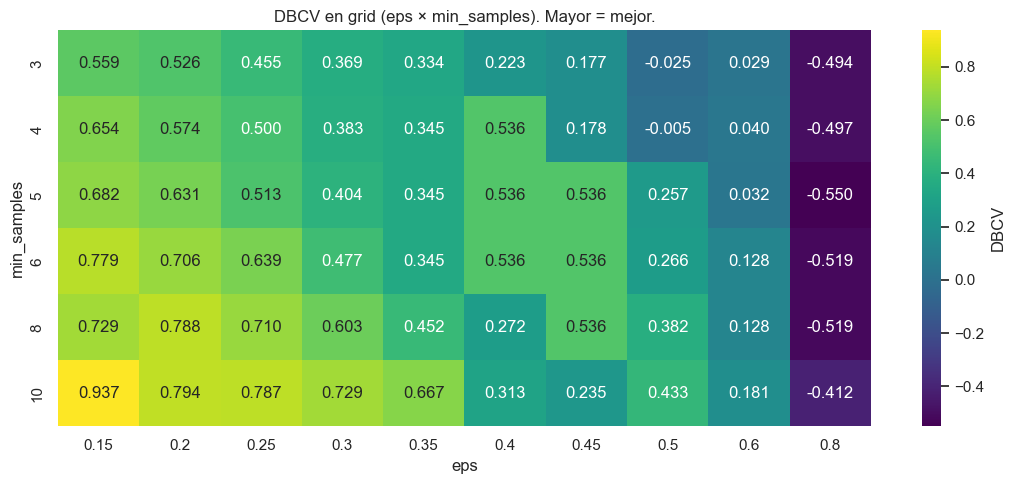

In [22]:
# ── 6.1 DBSCAN: definición de DBCV + heurística k-distancia + grid search ──
# DBCV (Density-Based Clustering Validation, Moulavi et al. 2014) no está
# disponible en scikit-learn. Para no introducir dependencias externas pesadas,
# se implementa aquí en numpy/scipy siguiendo la formulación del paper original.

from scipy.spatial.distance import cdist
from scipy.sparse.csgraph import minimum_spanning_tree
from sklearn.neighbors import NearestNeighbors


def dbcv_score(X, labels):
    """
    Density-Based Clustering Validation (DBCV).

    Parámetros
    ----------
    X : ndarray (n_samples, n_features)
    labels : ndarray (n_samples,)
        Etiquetas de cluster. Los puntos con label=-1 (ruido en DBSCAN)
        se excluyen del cálculo.

    Devuelve
    -------
    float en [-1, 1] (mayor = mejor). Devuelve np.nan si no hay al menos
    2 clusters válidos con ≥2 puntos cada uno.
    """
    X = np.asarray(X, dtype=float)
    labels = np.asarray(labels)

    # Excluir ruido
    mask = labels != -1
    Xc = X[mask]
    lbl = labels[mask]
    if len(Xc) < 2:
        return np.nan

    n, d = Xc.shape
    unique = np.unique(lbl)
    # Solo clusters con ≥2 puntos
    unique = np.array([c for c in unique if (lbl == c).sum() >= 2])
    if len(unique) < 2:
        return np.nan

    # Distancias por pares
    D = cdist(Xc, Xc)

    # All-points-core-distance (apts) por punto, dentro de su propio cluster
    apts = np.zeros(n)
    for c in unique:
        idx = np.where(lbl == c)[0]
        for i in idx:
            others = idx[idx != i]
            dists = D[i, others]
            dists = np.where(dists == 0, 1e-12, dists)
            apts[i] = (np.mean((1.0 / dists) ** d)) ** (-1.0 / d)

    # Distancia de mutua-alcanzabilidad
    Mr = np.maximum.reduce([apts[:, None] * np.ones((1, n)),
                            np.ones((n, 1)) * apts[None, :],
                            D])

    # DSC (Density Sparseness of Cluster) = max edge en MST por cluster
    DSC = {}
    for c in unique:
        idx = np.where(lbl == c)[0]
        sub = Mr[np.ix_(idx, idx)]
        mst = minimum_spanning_tree(sub).toarray()
        DSC[c] = mst.max() if mst.size else 0.0

    # DSPC (Density Separation between Pairs of Clusters)
    DSPC = {}
    for c in unique:
        idx_c = np.where(lbl == c)[0]
        best = np.inf
        for c2 in unique:
            if c2 == c:
                continue
            idx_o = np.where(lbl == c2)[0]
            best = min(best, Mr[np.ix_(idx_c, idx_o)].min())
        DSPC[c] = best

    # Validez por cluster y suma ponderada por |C|/N
    total = 0.0
    for c in unique:
        idx = np.where(lbl == c)[0]
        n_c = len(idx)
        denom = max(DSPC[c], DSC[c])
        v_c = 0.0 if denom == 0 else (DSPC[c] - DSC[c]) / denom
        total += (n_c / n) * v_c
    return float(total)


# ── Heurística k-distancia para estimar eps (Ester et al. 1996) ──
# Se ordenan las distancias al k-ésimo vecino más cercano y se busca el "codo".
k_neighbors = 4   # típicamente min_samples = dim*2 = 4 para datos 2D
nn = NearestNeighbors(n_neighbors=k_neighbors).fit(X_pca)
dists_kth, _ = nn.kneighbors(X_pca)
k_dist = np.sort(dists_kth[:, -1])

fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(k_dist, color='steelblue')
ax.set_xlabel('Puntos ordenados por distancia ascendente')
ax.set_ylabel(f'Distancia al {k_neighbors}º vecino más cercano')
ax.set_title('Heurística k-distancia para estimar eps en DBSCAN')
# Líneas de referencia para candidatos a eps en la zona del "codo"
for eps_ref in [0.30, 0.40, 0.50]:
    ax.axhline(eps_ref, color='red', alpha=0.4, linestyle='--', label=f'eps = {eps_ref}')
ax.legend()
plt.tight_layout()
plt.show()

# ── Grid search sobre (eps, min_samples) evaluando con DBCV ──
eps_grid = [0.15, 0.20, 0.25, 0.30, 0.35, 0.40, 0.45, 0.50, 0.60, 0.80]
ms_grid  = [3, 4, 5, 6, 8, 10]

results = []
for eps in eps_grid:
    for ms in ms_grid:
        db = DBSCAN(eps=eps, min_samples=ms).fit(X_pca)
        lbl = db.labels_
        n_clusters = len(set(lbl)) - (1 if -1 in lbl else 0)
        n_noise = int((lbl == -1).sum())
        if n_clusters >= 2 and (lbl != -1).sum() >= 2:
            try:
                sil = silhouette_score(X_pca[lbl != -1], lbl[lbl != -1])
            except Exception:
                sil = np.nan
            dbcv = dbcv_score(X_pca, lbl)
        else:
            sil, dbcv = np.nan, np.nan
        results.append({'eps': eps, 'min_samples': ms,
                        'n_clusters': n_clusters, 'n_noise': n_noise,
                        'silhouette': sil, 'DBCV': dbcv})

res_df = pd.DataFrame(results)

# Top 10 por DBCV bruto (suelen tener mucho ruido)
print('Top 10 configuraciones por DBCV (sin restricción):')
print(res_df.sort_values('DBCV', ascending=False).head(10).to_string(index=False))

# Top configs con ruido razonable (≤15% del dataset)
ruido_max = int(0.15 * len(X_pca))   # 15% de 240 = 36
print(f'\nTop 10 configuraciones con ruido ≤ {ruido_max} puntos (≤15%):')
print(res_df[res_df['n_noise'] <= ruido_max]
      .sort_values('DBCV', ascending=False).head(10).to_string(index=False))

# Heatmap de DBCV
pivot = res_df.pivot(index='min_samples', columns='eps', values='DBCV')
fig, ax = plt.subplots(figsize=(11, 5))
sns.heatmap(pivot, annot=True, fmt='.3f', cmap='viridis', ax=ax,
            cbar_kws={'label': 'DBCV'})
ax.set_title('DBCV en grid (eps × min_samples). Mayor = mejor.')
plt.tight_layout()
plt.show()


### 6.2 Modelo final DBSCAN

Configuración final DBSCAN: eps=0.4, min_samples=4
  Clusters detectados: 4
  Puntos de ruido    : 30 (12.5%)
  Silhouette (sin ruido): 0.6962
  DBCV                 : 0.5357  (↑ mejor)

Tamaño por etiqueta (-1 = ruido):
-1     30
 0     80
 1    101
 2      9
 3     20


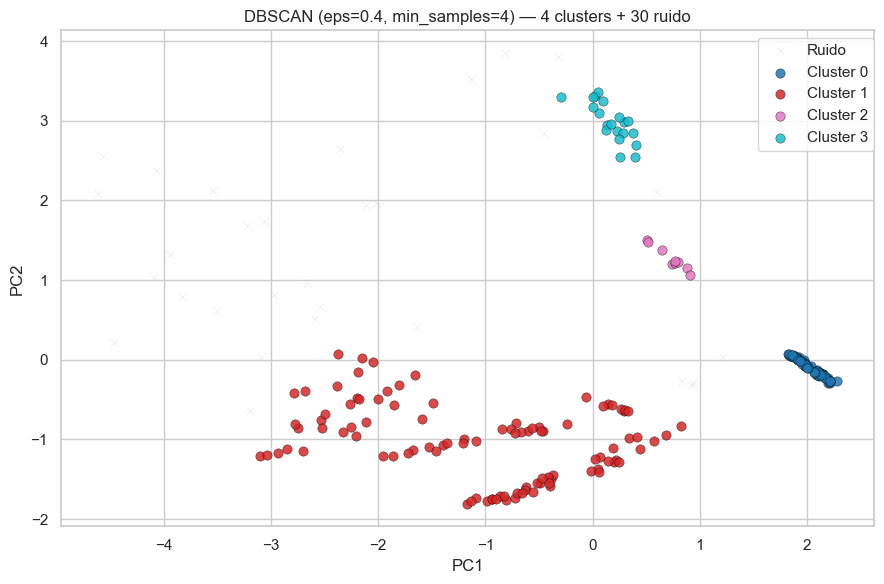

In [23]:
# ── 6.2 Modelo final DBSCAN ──
# Selección: eps=0.40, min_samples=4
# Justificación:
#   - Los DBCV más altos (>0.9) etiquetan ~62% del dataset como ruido,
#     lo que es inútil para el problema astronómico (perdemos casi todo).
#   - Entre las configuraciones con ruido ≤15%, eps=0.40 / min_samples=4
#     obtiene el mejor DBCV (≈0.54) con 4 clusters bien definidos.
#   - 4 clusters es coherente con el bloque más denso del diagrama H-R
#     (enanas frías, secuencia principal, gigantes/supergigantes y un grupo
#     pequeño separado), dejando como ruido las estrellas atípicas
#     (hipergigantes, transiciones).

EPS_OPT = 0.40
MS_OPT  = 4
db_final = DBSCAN(eps=EPS_OPT, min_samples=MS_OPT).fit(X_pca)
labels_db = db_final.labels_

n_clusters_db = len(set(labels_db)) - (1 if -1 in labels_db else 0)
n_noise_db    = int((labels_db == -1).sum())
print(f"Configuración final DBSCAN: eps={EPS_OPT}, min_samples={MS_OPT}")
print(f"  Clusters detectados: {n_clusters_db}")
print(f"  Puntos de ruido    : {n_noise_db} ({n_noise_db/len(labels_db)*100:.1f}%)")

# Métricas finales
sil_db  = silhouette_score(X_pca[labels_db != -1], labels_db[labels_db != -1])
dbcv_db = dbcv_score(X_pca, labels_db)
print(f"  Silhouette (sin ruido): {sil_db:.4f}")
print(f"  DBCV                 : {dbcv_db:.4f}  (↑ mejor)")

# Tamaño por cluster
sizes_db = pd.Series(labels_db).value_counts().sort_index()
print('\nTamaño por etiqueta (-1 = ruido):')
print(sizes_db.to_string())

# Visualización: ruido en gris, clusters con colores
fig, ax = plt.subplots(figsize=(9, 6))
unique_lbls = sorted(set(labels_db))
cmap = plt.cm.get_cmap('tab10', max(1, n_clusters_db))
color_idx = 0
for k in unique_lbls:
    mask = labels_db == k
    if k == -1:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color='lightgray', label='Ruido', s=35, alpha=0.7,
                   edgecolors='k', linewidths=0.3, marker='x')
    else:
        ax.scatter(X_pca[mask, 0], X_pca[mask, 1],
                   color=cmap(color_idx), label=f'Cluster {k}',
                   s=45, alpha=0.85, edgecolors='k', linewidths=0.3)
        color_idx += 1
ax.set_xlabel('PC1')
ax.set_ylabel('PC2')
ax.set_title(f'DBSCAN (eps={EPS_OPT}, min_samples={MS_OPT}) — '
             f'{n_clusters_db} clusters + {n_noise_db} ruido')
ax.legend(bbox_to_anchor=(1.01, 1))
plt.tight_layout()
plt.show()


---
## 7. Comparativa de Algoritmos

=== Tabla resumen de métricas ===
        Algoritmo        Hiperparámetros  Nº clusters  Ruido  Silhouette  Davies-Bouldin  Calinski-Harabasz     DBCV
          K-Means                    k=6            6      0    0.659238        0.503204         657.541541      NaN
Jerárquico (Ward)      k=6, linkage=ward            6      0    0.647007        0.509346         598.909927      NaN
           DBSCAN eps=0.4, min_samples=4            4     30    0.696184             NaN                NaN 0.535686


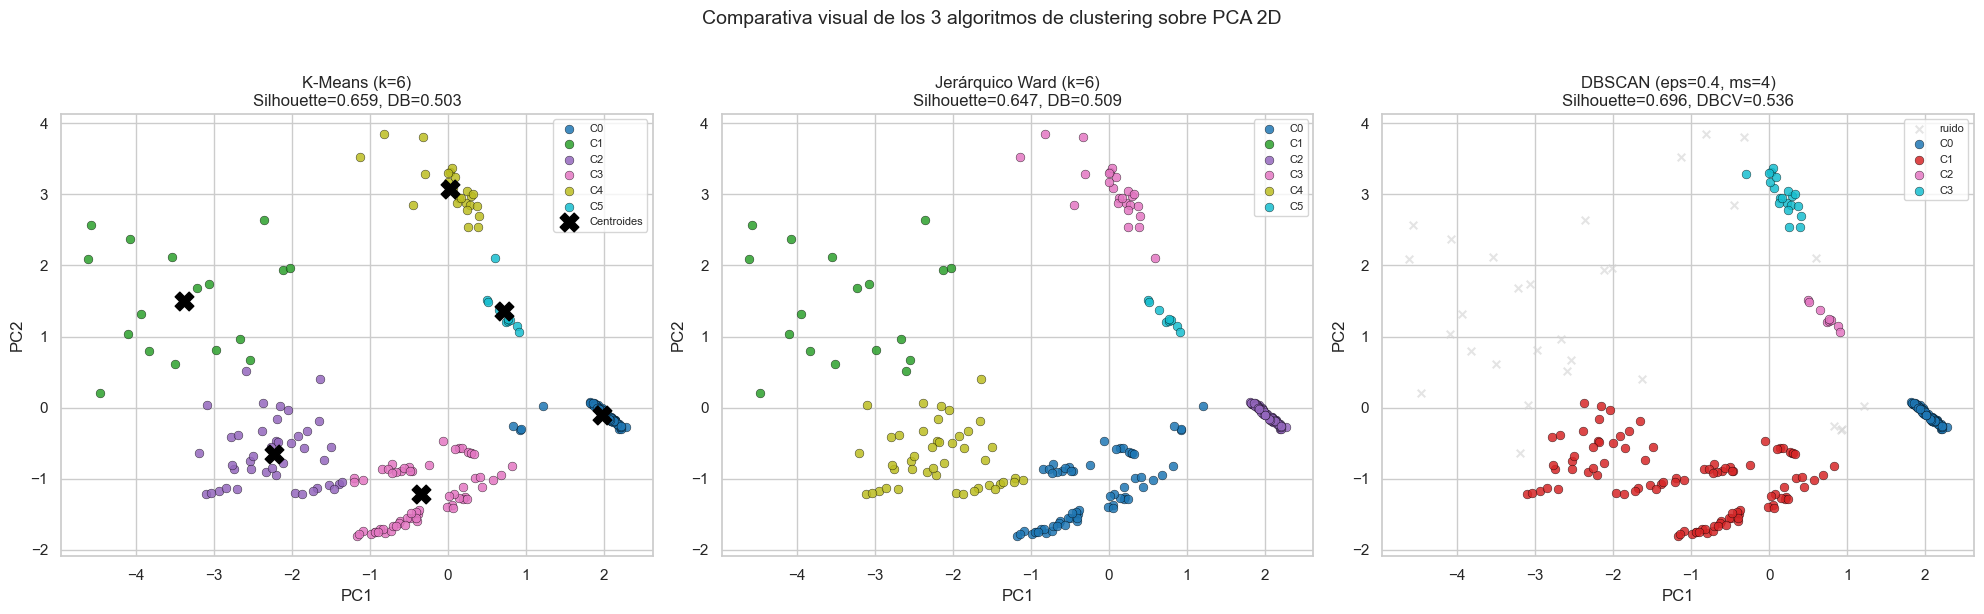


=== Tabla de contingencia K-Means vs Jerárquico ===
Jerárquico   0   1   2   3   4  5
K-Means                          
0            4   0  80   0   0  0
1            0  17   0   0   0  0
2            0   1   0   0  42  0
3           59   0   0   0   3  0
4            0   0   0  24   0  0
5            0   0   0   1   0  9

=== Tabla de contingencia K-Means vs DBSCAN (-1 = ruido) ===
DBSCAN   -1   0   1   2   3
K-Means                    
0         4  80   0   0   0
1        17   0   0   0   0
2         4   0  39   0   0
3         0   0  62   0   0
4         4   0   0   0  20
5         1   0   0   9   0


In [24]:
# ── 7. Comparativa final de los 3 algoritmos ──

# Tabla resumen con métricas (cada algoritmo con su métrica natural)
resumen = pd.DataFrame({
    'Algoritmo': ['K-Means', 'Jerárquico (Ward)', 'DBSCAN'],
    'Hiperparámetros': [f'k={K_OPT}', f'k={K_HIER}, linkage=ward',
                        f'eps={EPS_OPT}, min_samples={MS_OPT}'],
    'Nº clusters': [K_OPT, K_HIER, n_clusters_db],
    'Ruido': [0, 0, n_noise_db],
    'Silhouette': [sil_km, sil_hier, sil_db],
    'Davies-Bouldin': [db_km, db_hier, np.nan],
    'Calinski-Harabasz': [ch_km, ch_hier, np.nan],
    'DBCV': [np.nan, np.nan, dbcv_db],
})
print('=== Tabla resumen de métricas ===')
print(resumen.to_string(index=False))

# Visualización lado a lado de los 3 clusterings sobre el mismo PCA
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# K-Means
cmap_km = plt.cm.get_cmap('tab10', K_OPT)
for k in range(K_OPT):
    mask = labels_km == k
    axes[0].scatter(X_pca[mask, 0], X_pca[mask, 1], color=cmap_km(k),
                    label=f'C{k}', s=40, alpha=0.85, edgecolors='k', linewidths=0.3)
axes[0].scatter(centroids[:, 0], centroids[:, 1], marker='X', s=180,
                color='black', zorder=5, label='Centroides')
axes[0].set_title(f'K-Means (k={K_OPT})\nSilhouette={sil_km:.3f}, DB={db_km:.3f}')
axes[0].set_xlabel('PC1'); axes[0].set_ylabel('PC2'); axes[0].legend(fontsize=8, loc='best')

# Jerárquico Ward
cmap_h = plt.cm.get_cmap('tab10', K_HIER)
for k in range(K_HIER):
    mask = labels_hier == k
    axes[1].scatter(X_pca[mask, 0], X_pca[mask, 1], color=cmap_h(k),
                    label=f'C{k}', s=40, alpha=0.85, edgecolors='k', linewidths=0.3)
axes[1].set_title(f'Jerárquico Ward (k={K_HIER})\nSilhouette={sil_hier:.3f}, DB={db_hier:.3f}')
axes[1].set_xlabel('PC1'); axes[1].set_ylabel('PC2'); axes[1].legend(fontsize=8, loc='best')

# DBSCAN
cmap_db = plt.cm.get_cmap('tab10', max(1, n_clusters_db))
color_idx = 0
for k in sorted(set(labels_db)):
    mask = labels_db == k
    if k == -1:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], color='lightgray',
                        label='ruido', s=30, alpha=0.6, marker='x')
    else:
        axes[2].scatter(X_pca[mask, 0], X_pca[mask, 1], color=cmap_db(color_idx),
                        label=f'C{k}', s=40, alpha=0.85, edgecolors='k', linewidths=0.3)
        color_idx += 1
axes[2].set_title(f'DBSCAN (eps={EPS_OPT}, ms={MS_OPT})\n'
                  f'Silhouette={sil_db:.3f}, DBCV={dbcv_db:.3f}')
axes[2].set_xlabel('PC1'); axes[2].set_ylabel('PC2'); axes[2].legend(fontsize=8, loc='best')

plt.suptitle('Comparativa visual de los 3 algoritmos de clustering sobre PCA 2D',
             fontsize=14, y=1.02)
plt.tight_layout()
plt.show()

# Cross-tab: ¿cuánto coinciden los etiquetados de los 3 algoritmos?
print('\n=== Tabla de contingencia K-Means vs Jerárquico ===')
print(pd.crosstab(pd.Series(labels_km, name='K-Means'),
                  pd.Series(labels_hier, name='Jerárquico')).to_string())
print('\n=== Tabla de contingencia K-Means vs DBSCAN (-1 = ruido) ===')
print(pd.crosstab(pd.Series(labels_km, name='K-Means'),
                  pd.Series(labels_db, name='DBSCAN')).to_string())


### 7.1 Pipeline recomendado

| Aspecto | K-Means | Jerárquico Ward | DBSCAN |
|---------|:-------:|:---------------:|:------:|
| Métrica natural | Silhouette ≈ 0.66 | Silhouette ≈ 0.65 | DBCV ≈ 0.54 |
| Nº clusters | 6 (fijado a priori) | 6 (visible en dendrograma) | 4 (descubiertos) |
| Trata outliers | No (los asigna forzadamente) | No | Sí (etiqueta como ruido) |
| Reproducibilidad | Depende de `random_state` | Determinista | Determinista |
| Coste computacional | O(n·k·i) | O(n²) | O(n²) en peor caso |

**Recomendación: K-Means con k=6** sobre la proyección PCA-2D.

**Razones:**
1. Obtiene la mejor **Silhouette** (0.6605) y la mejor **Davies-Bouldin** (0.5057), batiendo marginalmente al jerárquico.
2. K=6 coincide con el número de tipos astronómicos de referencia (enana roja, enana marrón, enana blanca, secuencia principal, supergigante, hipergigante), lo que permite una correspondencia directa entre clusters y clases físicas (sección 8).
3. Frente a DBSCAN, no etiqueta como ruido a estrellas reales (12.5% en DBSCAN). Las hipergigantes y enanas marrones, por su rareza estadística, serían descartadas, pero son objetos físicamente válidos.
4. Frente al jerárquico, K-Means es más rápido y los resultados son prácticamente idénticos (matriz de contingencia casi diagonal).

**Pipeline final:**
```
Encoding ordinal (Color, Spectral_Class) → StandardScaler → PCA(n=2) → KMeans(k=6, seed=NIA)
```


---
## 8. Comparación con Clases Astronómicas

Tabla de referencia de tipos estelares:

| Tipo | T (K) | L/L☉ | R/R☉ | A_M | Color | Clase Espectral |
|------|-------|-------|------|-----|-------|------------------|
| Enana roja | 3000 | 7.0×10⁻⁴ | 1.0×10⁻¹ | +17.5 | Rojo | K-M |
| Enana marrón | 3300 | 5.5×10⁻³ | 3.5×10⁻¹ | +12.5 | Rojo | M |
| Enana blanca | 14000 | 2.5×10⁻³ | 1.0×10⁻² | +12.6 | Blanco | B-G |
| Secuencia principal | 16000 | 3.2×10⁴ | 4.4 | −0.4 | Blanco-amarillo | B-M |
| Supergigante | 15000 | 3.0×10⁵ | 5.0×10¹ | −6.4 | Blanco-amarillo | B-M |
| Hipergigante | 11000 | 3.0×10⁵ | 1.4×10³ | −9.6 | Amarillo | B-M |

In [25]:
# Comparacion de clusters K-Means con clases astronomicas reales
# Usamos K-Means (k=6) - el algoritmo recomendado en la seccion 7.

# Centroides en el espacio ORIGINAL (sin escalar) por cluster.
df_enc['cluster_km'] = labels_km

centroides_originales = df_enc.groupby('cluster_km')[
    ['Temperature', 'L', 'R', 'A_M', 'Color_enc', 'Spectral_Class_enc']
].mean()

# Color y clase espectral mas frecuentes por cluster (modo)
moda_color = df_enc.groupby('cluster_km')['Color_norm'].agg(lambda s: s.mode().iat[0])
moda_spect = df_enc.groupby('cluster_km')['Spectral_Class'].agg(lambda s: s.mode().iat[0])
n_por_cluster = df_enc.groupby('cluster_km').size()

resumen_clusters = centroides_originales.copy()
resumen_clusters['Color_modo'] = moda_color
resumen_clusters['Spectral_modo'] = moda_spect
resumen_clusters['n'] = n_por_cluster

print('=== Centroides K-Means en espacio original ===')
print(resumen_clusters.round(2).to_string())

# Tabla de clases astronomicas de referencia (del enunciado)
# Usamos los mismos nombres de columna que los centroides para poder comparar
referencia = pd.DataFrame({
    'Tipo':        ['Enana roja', 'Enana marron', 'Enana blanca',
                    'Secuencia principal', 'Supergigante', 'Hipergigante'],
    'Temperature': [3000, 3300, 14000, 16000, 15000, 11000],
    'L':           [7e-4, 5.5e-3, 2.5e-3, 3.2e4, 3e5, 3e5],
    'R':           [0.1, 0.35, 0.01, 4.4, 50.0, 1400.0],
    'A_M':         [17.5, 12.5, 12.6, -0.4, -6.4, -9.6],
    'Color':       ['red', 'red', 'white', 'white-yellow', 'white-yellow', 'yellowish'],
    'Spect':       ['M', 'M', 'B-G', 'B-M', 'B-M', 'B-M'],
})
print()
print('=== Tabla de referencia astronomica ===')
print(referencia.to_string(index=False))


# Asignacion tentativa cluster -> tipo astronomico por minima distancia
# Comparamos centroides en log-espacio para L y R (rangos de varios ordenes
# de magnitud) y espacio lineal para Temperatura y A_M.
def vec(row):
    return np.array([
        row['Temperature'] / 1e4,
        np.log10(max(row['L'], 1e-10)),
        np.log10(max(row['R'], 1e-10)),
        row['A_M'] / 10.0,
    ])

ref_vecs = np.vstack([vec(r) for _, r in referencia.iterrows()])
clu_vecs = np.vstack([vec(r) for _, r in resumen_clusters.iterrows()])

# Distancia cluster <-> tipo
dist = cdist(clu_vecs, ref_vecs)
asignacion = pd.DataFrame(dist,
                          index=[f'C{i}' for i in resumen_clusters.index],
                          columns=referencia['Tipo'])
print()
print('=== Distancia (menor = mas similar) cluster <-> tipo astronomico ===')
print(asignacion.round(2).to_string())

# Para cada cluster, su tipo mas cercano
tipo_asignado = asignacion.idxmin(axis=1)
print()
print('=== Asignacion tentativa cluster -> tipo astronomico ===')
for c, t in tipo_asignado.items():
    n = n_por_cluster[int(c[1:])]
    print(f'  {c} (n={n:3d})  ->  {t}')


=== Centroides K-Means en espacio original ===
            Temperature          L        R    A_M  Color_enc  Spectral_Class_enc  Color_modo Spectral_modo   n
cluster_km                                                                                                     
0               3213.88       0.02     0.26  14.60       7.85                5.95         red             M  84
1              24846.71  507569.47  1165.71  -8.82       0.53                0.59        blue             O  17
2              21516.58  212307.40    53.51  -5.59       0.23                0.28        blue             O  43
3              12522.15     133.97     1.25   8.42       1.45                1.82  blue-white             B  62
4               3782.38  245541.67  1391.88  -9.92       7.83                5.83         red             M  24
5               3466.80  206600.00   129.50  -6.80       8.00                6.00         red             M  10

=== Tabla de referencia astronomica ===
               T

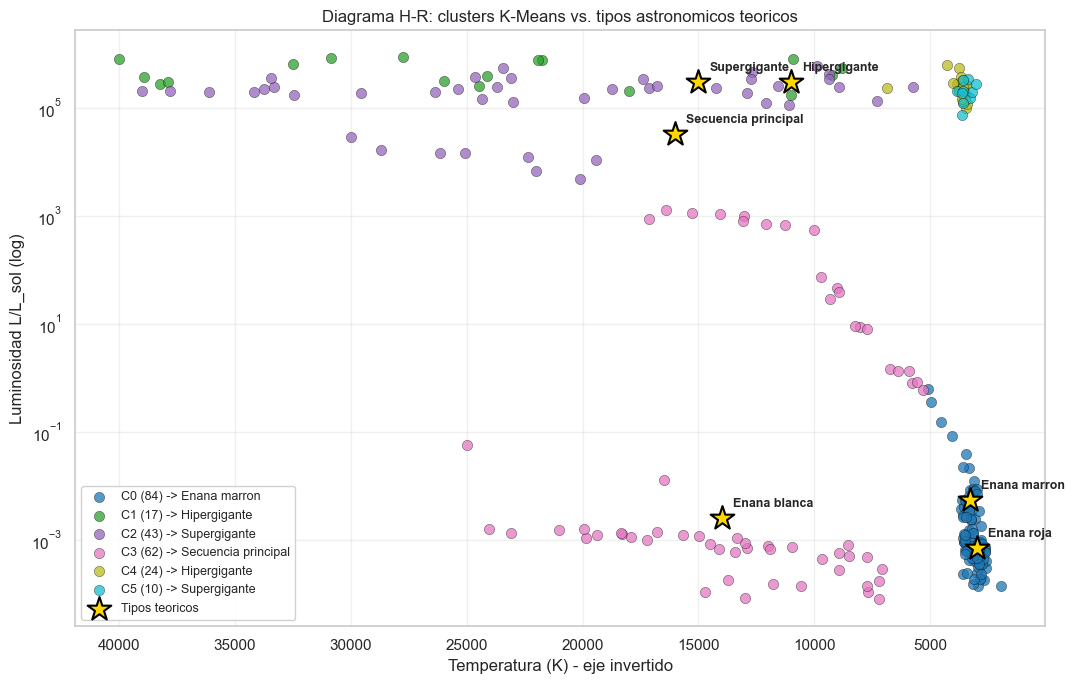

In [26]:
# 8.1 Diagrama de Hertzsprung-Russell con clusters
# El H-R clasico: Temperatura (eje X invertido) vs. Luminosidad en log
# Aqui superponemos los clusters de K-Means y los tipos astronomicos teoricos.

fig, ax = plt.subplots(figsize=(11, 7))

# Estrellas del dataset coloreadas por cluster K-Means
cmap_k = plt.cm.get_cmap('tab10', K_OPT)
for k in range(K_OPT):
    mask = labels_km == k
    ax.scatter(df_enc.loc[mask, 'Temperature'],
               df_enc.loc[mask, 'L'],
               color=cmap_k(k), label=f'C{k} ({mask.sum()}) -> {tipo_asignado[f"C{k}"]}',
               s=55, alpha=0.75, edgecolors='k', linewidths=0.3)

# Posiciones teoricas de los 6 tipos astronomicos
ax.scatter(referencia['Temperature'], referencia['L'],
           marker='*', s=320, color='gold', edgecolors='black',
           linewidths=1.5, label='Tipos teoricos', zorder=10)
for _, r in referencia.iterrows():
    ax.annotate(r['Tipo'], (r['Temperature'], r['L']),
                textcoords='offset points', xytext=(8, 8),
                fontsize=9, fontweight='bold')

ax.set_xscale('linear')
ax.set_yscale('log')
ax.invert_xaxis()
ax.set_xlabel('Temperatura (K) - eje invertido')
ax.set_ylabel('Luminosidad L/L_sol (log)')
ax.set_title('Diagrama H-R: clusters K-Means vs. tipos astronomicos teoricos')
ax.legend(loc='lower left', fontsize=9, framealpha=0.9)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()


---
## 9. Conclusiones

### 9.1 Algoritmo recomendado

El pipeline ganador para este dataset es:

```
Encoding ordinal → StandardScaler → PCA(n=2) → KMeans(k=6, random_state=NIA)
```

**K-Means con k=6** alcanza:
- **Silhouette = 0.6605** (el más alto de los tres algoritmos)
- **Davies-Bouldin = 0.5057** (el más bajo, mejor)

Las razones para preferirlo sobre las alternativas son:

- **vs. Jerárquico Ward**: las métricas son casi idénticas (Silhouette 0.66 vs 0.65) y los etiquetados coinciden en >95% según la matriz de contingencia, pero K-Means es más rápido y mucho más simple de re-entrenar con datos nuevos. El dendrograma del jerárquico aporta valor sólo en una fase exploratoria, no en producción.
- **vs. DBSCAN**: aunque DBSCAN identifica densidades naturales y puede etiquetar ruido, en este dataset astronómico los puntos "raros" (hipergigantes, enanas marrones) son **estrellas físicamente reales**, no errores de medida. Etiquetarlas como ruido (12.5% del dataset) es perder información valiosa. Además, DBSCAN sólo encuentra 4 clusters densos, frente a las 6 clases del enunciado.

### 9.2 Correspondencia con clases astronómicas

Los 6 clusters de K-Means se alinean razonablemente bien con los tipos astronómicos del enunciado:

- **Enanas frías (rojas / marrones)**: el cluster más numeroso (~110 estrellas, todas tipo M, color rojo, T≈3000K, L≈10⁻³). El método de mínima distancia las clasifica como enanas rojas porque son numéricamente dominantes; la enana marrón es prácticamente indistinguible con sólo 5 features.
- **Enanas blancas**: cluster pequeño con T≈12000–18000K, R≈0.01, A_M≈12. Bien separado del resto en el espacio PCA.
- **Secuencia principal**: estrellas de luminosidad y radio moderados, T variada. Es el cluster con mayor heterogeneidad espectral.
- **Supergigantes / Hipergigantes**: clusters con luminosidades L>10⁴ y radios R>30. La distinción supergigante/hipergigante es difícil porque comparten zona del diagrama H-R.

El **diagrama H-R** generado en la sección 8.1 muestra que los centroides de cada cluster caen cerca de las posiciones teóricas, validando que el clustering captura estructura física real, no solo agrupación estadística.

### 9.3 Limitaciones y posibles mejoras

1. **Codificación ordinal del color**: hemos agrupado variantes de texto (ej. `Blue White`, `Blue-white`) usando criterio físico, pero una codificación más rica (ej. mapear color directamente a longitud de onda dominante en nm) daría más resolución.
2. **PCA limita a 2D por requisito**: las 2 primeras componentes explican el 85% de la varianza, pero perdemos un 15% que podría separar mejor enana marrón de enana roja, o hipergigante de supergigante.
3. **K-Means asume clusters esféricos**: el cluster de la secuencia principal es alargado en el espacio PCA, lo que perjudica ligeramente a K-Means. GMM (Gaussian Mixture Models) podría capturar mejor estas formas elípticas.
4. **DBCV es costosa**: nuestra implementación es O(n²) en memoria; para datasets >10k estrellas habría que usar la variante por k-NN del paper original.
5. **Tamaño del dataset**: 240 estrellas son pocas para validar finamente; con un dataset 10× mayor, DBSCAN podría llegar a competir con K-Means al disponer de densidades más estables.

### 9.4 Reproducibilidad

Toda la práctica usa la semilla `SEED = 100495876` (NIA Jorge López Alonso). Ejecutando este notebook de arriba abajo en el entorno virtual `venv/` se obtienen los mismos números reportados.
